# 01 · Oferta de cuidado en el DENUE — Ciudad de México

**Propósito.** Identificar qué establecimientos del DENUE corresponden a servicios de cuidado para
personas mayores y con discapacidad, contarlos por alcaldía y probar con datos propios, a escala de alcaldía,
el supuesto de "desiertos de cuidado" que hoy el informe integrador cita sin análisis que lo respalde.

**Qué NO hace este notebook.** No estima capacidad (plazas/cupos): el DENUE no la mide.
No trabaja a nivel AGEB/manzana contra demanda: eso requiere el Censo 2020 por manzana, que todavía no está en el repositorio.

**Fuentes**
| Archivo | Origen | Unidad de observación | Clave | Notas |
|---|---|---|---|---|
| `data/raw/denue_inegi_09_.csv` | INEGI, DENUE 05_2026 (modificado 2026-05-20), Términos de Libre Uso | Establecimiento | `id` / `clee` | Clasificado con **SCIAN 2018** (según su diccionario de datos) |
| `data/ref/Población de más de 60 años.csv` | Archivo del proyecto; **origen y año sin documentar** | Alcaldía × grupo de edad | `NOM_MUN` + `GRUPO_EDAD` | Valores = % de la población total de la CDMX |
| `data/ref/Capacidad disponible en residencias permanentes...csv` | Archivo del proyecto; **origen y año sin documentar** | Alcaldía | `Alcaldia` | Solo residencias privadas, 12 alcaldías |

El DENUE es un directorio: no tiene factor de expansión y cada fila es un establecimiento, no una muestra.


In [3]:
from pathlib import Path
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path('..')
RAW = RAIZ / 'data' / 'raw' / 'denue_inegi_09_.csv'
REF = RAIZ / 'data' / 'ref'
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
pd.set_option('display.max_colwidth', 80)

## 1. Carga y validación

In [4]:
denue = pd.read_csv(RAW, encoding='latin-1', dtype=str)
print('Filas:', len(denue), '| columnas:', denue.shape[1])
assert denue['id'].is_unique, 'id duplicado'
assert set(denue['cve_ent']) == {'09'}, 'hay registros fuera de la CDMX'
print('Alcaldías:', denue['cve_mun'].nunique())
print('Registros sin coordenadas:', denue[['latitud','longitud']].isna().any(axis=1).sum())

Filas: 462732 | columnas: 42
Alcaldías: 16
Registros sin coordenadas: 0


## 2. Verificación de las claves SCIAN propuestas en la delimitación

La delimitación consolidada (NotebookLM) propone `624410`, `624120` y `624310`. Esas son claves NAICS de EE. UU.;
el SCIAN México separa sector privado (terminación 1) y público (terminación 2). Se comprueba contra el propio archivo:

In [5]:
propuestas = ['624410', '624120', '624310']
print({c: int((denue['codigo_act'] == c).sum()) for c in propuestas})

(denue[denue['codigo_act'].str[:3].isin(['623', '624'])]
   .groupby(['codigo_act', 'nombre_act']).size().rename('establecimientos').to_frame())

{'624410': 0, '624120': 0, '624310': 0}


,,establecimientos
codigo_act,nombre_act,
623111,"Residencias del sector privado con cuidados de enfermeras para enfermos convalecientes, en rehabilitación, incurables y terminales",12
623112,"Residencias del sector público con cuidados de enfermeras para enfermos convalecientes, en rehabilitación, incurables y terminales",4
623211,Residencias del sector privado para el cuidado de personas con problemas de retardo mental,17
623212,Residencias del sector público para el cuidado de personas con problemas de retardo mental,1
623221,Residencias del sector privado para el cuidado de personas con problemas de trastorno mental y adicción,34
623222,Residencias del sector público para el cuidado de personas con problemas de trastorno mental y adicción,11
623311,Asilos y otras residencias del sector privado para el cuidado de ancianos,88
623312,Asilos y otras residencias del sector público para el cuidado de ancianos,21
623991,Orfanatos y otras residencias de asistencia social del sector privado,107


## 3. Catálogo de clases de cuidado (decisión del equipo, editable)

El catálogo vive en `catalogo_scian_cuidado.csv`, no en el código, para que el cambio de criterio quede versionado.
- **nucleo**: asilos y centros de día (personas mayores/discapacidad). Es lo que se usa en la comparación por alcaldía.
- **ampliado**: servicios relacionados que no son exclusivos de la población objetivo.
- **fuera_poblacion_objetivo / excluido_por_ahora**: se reportan pero no entran al análisis.

In [6]:
cat = pd.read_csv('catalogo_scian_cuidado.csv', dtype=str)
cuidado = denue.merge(cat, on='codigo_act', how='inner')
cuidado['sector'] = cuidado['codigo_act'].str[-1].map({'1': 'privado', '2': 'público'})
resumen = (cuidado.groupby(['grupo', 'codigo_act', 'nombre_act', 'sector'])
                  .size().rename('establecimientos').reset_index())
resumen

,grupo,codigo_act,nombre_act,sector,establecimientos
0,ampliado,621341,"Consultorios del sector privado de audiología y de terapia ocupacional, físi...",privado,536
1,ampliado,621342,"Consultorios del sector público de audiología y de terapia ocupacional, físi...",público,23
2,ampliado,623111,Residencias del sector privado con cuidados de enfermeras para enfermos conv...,privado,12
3,ampliado,623112,Residencias del sector público con cuidados de enfermeras para enfermos conv...,público,4
4,ampliado,623211,Residencias del sector privado para el cuidado de personas con problemas de ...,privado,17
5,ampliado,623212,Residencias del sector público para el cuidado de personas con problemas de ...,público,1
6,excluido_por_ahora,624311,Servicios de capacitación para el trabajo prestados por el sector privado pa...,privado,10
7,excluido_por_ahora,624312,Servicios de capacitación para el trabajo prestados por el sector público pa...,público,13
8,fuera_poblacion_objetivo,624411,Guarderías del sector privado,privado,340
9,fuera_poblacion_objetivo,624412,Guarderías del sector público,público,263


In [7]:
resumen.groupby('grupo')['establecimientos'].sum()

grupo
ampliado                    593
excluido_por_ahora           23
fuera_poblacion_objetivo    603
nucleo                      235
Name: establecimientos, dtype: int64

## 4. Calidad de la clasificación: revisión de nombres

La clase SCIAN la asigna el INEGI por actividad principal; no es garantía de que el lugar sea lo que dice la clase.
Se listan los nombres del núcleo que no contienen palabras típicas de cuidado, para revisión manual.

In [8]:
def norm(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode()
    return s.upper()

nucleo = cuidado[cuidado['grupo'] == 'nucleo'].copy()
patron = r'ASILO|ANCIAN|ADULTO|MAYOR|GERIATR|RESIDENCIA|ESTANCIA|CASA|HOGAR|DIA|DIF|INAPAM|ALZHEIMER|CUIDADO|ABUEL|SENIOR|VIDA|RETIRO|DISCAPACI'
nucleo['nombre_norm'] = nucleo['nom_estab'].map(norm)
dudosos = nucleo[~nucleo['nombre_norm'].str.contains(patron, regex=True)]
print(f'Núcleo: {len(nucleo)} | nombres sin palabra típica de cuidado: {len(dudosos)} ({len(dudosos)/len(nucleo):.0%})')
dudosos[['nom_estab', 'codigo_act', 'municipio', 'per_ocu']].sort_values('codigo_act')

Núcleo: 235 | nombres sin palabra típica de cuidado: 49 (21%)


,nom_estab,codigo_act,municipio,per_ocu
1283,PLENITUD EN ARMONIA,623311,Coyoacán,6 a 10 personas
1137,HERMANAS DE LA SAGRADA FAMILIA ORDEN DE SAN BENITO,623311,Gustavo A. Madero,0 a 5 personas
1147,HOSPITAL VICENTINO,623311,Álvaro Obregón,11 a 30 personas
19,ALMASANA HEALTH CLUB,623311,Miguel Hidalgo,0 a 5 personas
52,ASOCIACION DE AYUDA SOCIAL DE LA COMUNIDAD ALEMANA,623311,Xochimilco,31 a 50 personas
62,ATENCION INTEGRAL A LA SENECTUD LUZ AZTECA,623311,Iztapalapa,0 a 5 personas
80,BELMONT VILLAGE,623311,Cuajimalpa de Morelos,101 a 250 personas
1381,TECHO EDUCACION Y AYUDA,623311,La Magdalena Contreras,51 a 100 personas
1368,SMART LIFE RETIREMENT,623311,La Magdalena Contreras,0 a 5 personas
985,FUNDACION MIER Y PESADO,623311,Miguel Hidalgo,101 a 250 personas


In [9]:
dudosos[['id', 'nom_estab', 'codigo_act', 'municipio', 'per_ocu']].to_csv(OUT / 'revision_manual_nucleo.csv', index=False)

## 5. Por qué el DENUE no da capacidad

`per_ocu` es un **rango de personal ocupado**, no plazas. Un asilo con "11 a 30 personas" puede tener 10 o 80 residentes.
Convertir estratos en cupos exigiría un supuesto de razón personal/residente que hoy no tiene fuente.

In [10]:
orden = ['0 a 5 personas','6 a 10 personas','11 a 30 personas','31 a 50 personas',
         '51 a 100 personas','101 a 250 personas','251 y más personas']
pd.crosstab(nucleo['codigo_act'] + ' ' + nucleo['sector'], nucleo['per_ocu']).reindex(columns=orden, fill_value=0)

per_ocu,0 a 5 personas,6 a 10 personas,11 a 30 personas,31 a 50 personas,51 a 100 personas,101 a 250 personas,251 y más personas
row_0,,,,,,,
623311 privado,21,21,30,7,5,4,0
623312 público,8,3,8,2,0,0,0
624121 privado,12,4,6,0,0,0,0
624122 público,57,26,20,1,0,0,0


## 6. Oferta vs. población 60+ por alcaldía

Se compara la **participación** de cada alcaldía en los establecimientos del núcleo contra su **participación** en la población 60+.
El archivo de población está en % de la población total de la CDMX (las alcaldías suman el total de CDMX), así que las participaciones son comparables
aunque no tengamos conteos absolutos.

`indice = % de establecimientos / % de población 60+`. Mayor que 1: la alcaldía tiene más establecimientos de los que le tocarían por su población 60+.

**Limitaciones:** año del archivo de población desconocido; contar establecimientos no es contar plazas; que un servicio esté en una alcaldía no impide que atienda a residentes de otra.

In [11]:
def llave(s):
    s = norm(s).replace('.', '').strip()
    return {'CUAJIMALPA DE MORELOS': 'CUAJIMALPA'}.get(s, s)

p60 = pd.read_csv(REF / 'Población de más de 60 años.csv')
p60.columns = [c.strip() for c in p60.columns]
p60 = p60[p60['NOM_MUN'] != 'Ciudad de México']
pob = p60.groupby('NOM_MUN')['PORCENTAJE'].sum().reset_index()
pob['llave'] = pob['NOM_MUN'].map(llave)
pob['pct_pob60'] = pob['PORCENTAJE'] / pob['PORCENTAJE'].sum() * 100

of = nucleo.groupby('municipio').agg(establecimientos=('id', 'size'),
                                     asilos=('codigo_act', lambda s: s.isin(['623311','623312']).sum()),
                                     centros_dia=('codigo_act', lambda s: s.isin(['624121','624122']).sum()),
                                     publicos=('sector', lambda s: (s == 'público').sum())).reset_index()
of['llave'] = of['municipio'].map(llave)

comp = pob.merge(of, on='llave', how='outer', indicator=True)
assert (comp['_merge'] == 'both').all(), comp[comp['_merge'] != 'both']
comp = comp.drop(columns=['_merge', 'NOM_MUN', 'PORCENTAJE'])
comp['pct_establecimientos'] = comp['establecimientos'] / comp['establecimientos'].sum() * 100
comp['indice_oferta_vs_60'] = comp['pct_establecimientos'] / comp['pct_pob60']
comp = comp[['municipio','establecimientos','asilos','centros_dia','publicos','pct_establecimientos','pct_pob60','indice_oferta_vs_60']]
comp = comp.sort_values('indice_oferta_vs_60').reset_index(drop=True)
comp.round(2)

,municipio,establecimientos,asilos,centros_dia,publicos,pct_establecimientos,pct_pob60,indice_oferta_vs_60
0,Cuauhtémoc,7,5,2,2,2.98,6.29,0.47
1,Azcapotzalco,6,4,2,3,2.55,5.27,0.48
2,Iztacalco,6,2,4,5,2.55,4.75,0.54
3,Gustavo A. Madero,25,12,13,16,10.64,13.64,0.78
4,Venustiano Carranza,10,2,8,9,4.26,5.29,0.80
5,Iztapalapa,37,10,27,22,15.74,17.57,0.90
6,Miguel Hidalgo,11,8,3,3,4.68,4.77,0.98
7,Álvaro Obregón,22,9,13,12,9.36,8.20,1.14
8,Coyoacán,23,13,10,10,9.79,8.49,1.15
9,Tlalpan,21,15,6,3,8.94,7.30,1.22


### 6b. El resultado cambia según el tipo de servicio

La clase `624121/624122` mezcla centros de día de cuidado con clubes, grupos y "casas del adulto mayor" de carácter recreativo:
el SCIAN no distingue la intensidad del cuidado. Por eso se calcula el índice por separado para asilos (residencial) y para centros de día.

In [12]:
tipo = comp[['municipio', 'asilos', 'centros_dia', 'pct_pob60']].copy()
for c in ['asilos', 'centros_dia']:
    tipo[f'indice_{c}'] = (tipo[c] / tipo[c].sum() * 100) / tipo['pct_pob60']
etiqueta = nucleo['nom_estab'].map(norm).str.contains(r'CLUB|GRUPO|REUNION|CASA DEL ADULTO', regex=True)
print('Centros de día cuyo nombre indica club/grupo/casa del adulto mayor:',
      int((etiqueta & nucleo['codigo_act'].isin(['624121','624122'])).sum()),
      'de', int(nucleo['codigo_act'].isin(['624121','624122']).sum()))
tipo.sort_values('indice_asilos').round(2)

Centros de día cuyo nombre indica club/grupo/casa del adulto mayor: 59 de 126


,municipio,asilos,centros_dia,pct_pob60,indice_asilos,indice_centros_dia
15,Milpa Alta,0,6,1.10,0.00,4.32
4,Venustiano Carranza,2,8,5.29,0.35,1.20
2,Iztacalco,2,4,4.75,0.39,0.67
5,Iztapalapa,10,27,17.57,0.52,1.22
12,Tláhuac,2,8,3.10,0.59,2.05
1,Azcapotzalco,4,2,5.27,0.70,0.30
0,Cuauhtémoc,5,2,6.29,0.73,0.25
3,Gustavo A. Madero,12,13,13.64,0.81,0.76
7,Álvaro Obregón,9,13,8.20,1.01,1.26
8,Coyoacán,13,10,8.49,1.41,0.94


In [13]:
tipo.round(3).to_csv(OUT / 'indice_por_tipo_servicio.csv', index=False)

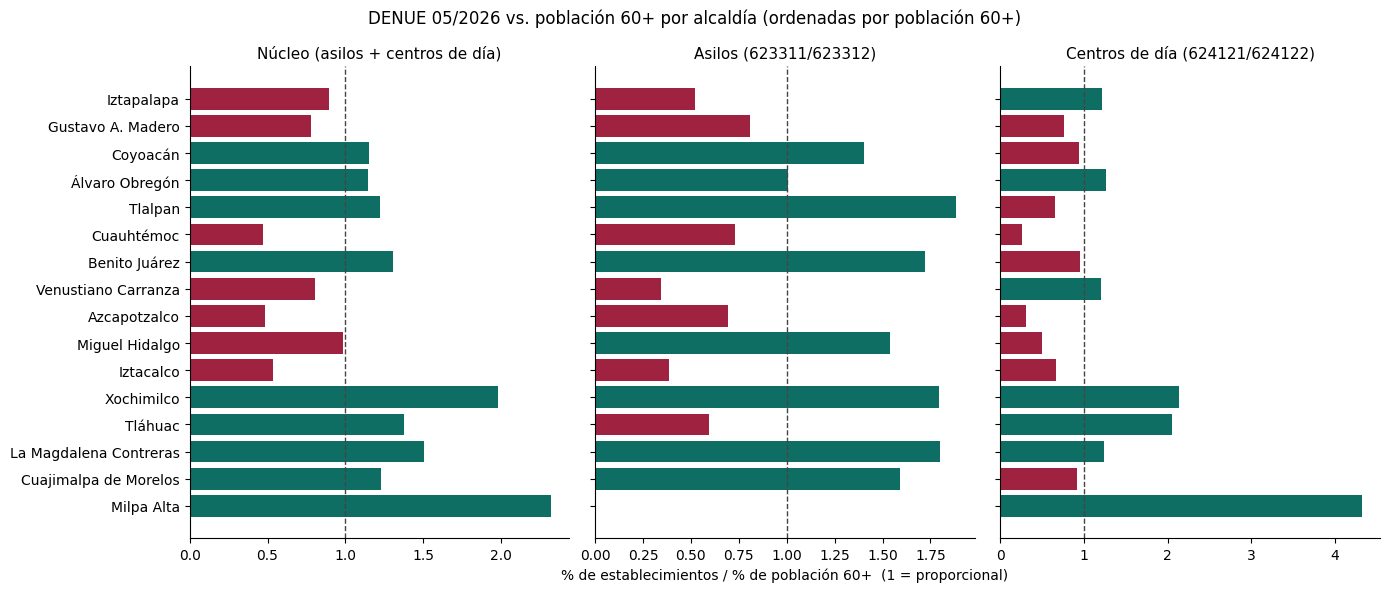

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
orden_m = comp.sort_values('pct_pob60')['municipio']
t = tipo.set_index('municipio').loc[orden_m]
c = comp.set_index('municipio').loc[orden_m]
paneles = [(c['indice_oferta_vs_60'], 'Núcleo (asilos + centros de día)'),
           (t['indice_asilos'], 'Asilos (623311/623312)'),
           (t['indice_centros_dia'], 'Centros de día (624121/624122)')]
for ax, (serie, titulo) in zip(axes, paneles):
    ax.barh(serie.index, serie.values, color=['#9F2241' if v < 1 else '#0F6E64' for v in serie.values])
    ax.axvline(1, color='#444', lw=1, ls='--')
    ax.set_title(titulo, fontsize=11)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
axes[1].set_xlabel('% de establecimientos / % de población 60+  (1 = proporcional)')
fig.suptitle('DENUE 05/2026 vs. población 60+ por alcaldía (ordenadas por población 60+)', fontsize=12)
plt.tight_layout(); plt.savefig(OUT / 'indice_oferta_vs_60_por_alcaldia.png', dpi=150); plt.show()

## 7. Contraste con el archivo de capacidad de residencias privadas

Si el DENUE fuera buen indicador de oferta, las alcaldías con más asilos privados (`623311`) deberían tener más capacidad.

In [15]:
cap = pd.read_csv(REF / 'Capacidad disponible en residencias permanentes de sector privado para adultos y adultas mayores.csv')
cap.columns = [c.strip() for c in cap.columns]
cap['llave'] = cap['Alcaldia'].map(llave)
asil_priv = (nucleo[nucleo['codigo_act'] == '623311'].groupby('municipio').size()
             .rename('asilos_privados_denue').reset_index())
asil_priv['llave'] = asil_priv['municipio'].map(llave)
cc = asil_priv.merge(cap[['llave', 'Capacidad_total']], on='llave', how='outer')
cc['municipio'] = cc['municipio'].fillna(cc['llave'].str.title())
cc = cc[['municipio', 'asilos_privados_denue', 'Capacidad_total']].sort_values('Capacidad_total', ascending=False)
print('Correlación de Spearman (alcaldías con ambos datos):',
      round(cc.dropna()[['asilos_privados_denue', 'Capacidad_total']].corr(method='spearman').iloc[0, 1], 2),
      '| n =', len(cc.dropna()))
cc

Correlación de Spearman (alcaldías con ambos datos): 0.27 | n = 12


,municipio,asilos_privados_denue,Capacidad_total
10,Miguel Hidalgo,7,439.0
11,Tlalpan,15,403.0
3,Coyoacán,11,361.0
5,Cuauhtémoc,5,197.0
1,Azcapotzalco,3,186.0
13,Xochimilco,7,158.0
0,Álvaro Obregón,7,140.0
2,Benito Juárez,8,102.0
9,La Magdalena Contreras,4,91.0
6,Gustavo A. Madero,8,76.0


## 8. Exportar resultados

In [16]:
comp.to_csv(OUT / 'oferta_nucleo_vs_pob60_por_alcaldia.csv', index=False)
resumen.to_csv(OUT / 'resumen_clases_cuidado.csv', index=False)
cc.to_csv(OUT / 'asilos_denue_vs_capacidad.csv', index=False)
sorted(p.name for p in OUT.iterdir())

['asilos_denue_vs_capacidad.csv',
 'indice_oferta_vs_60_por_alcaldia.png',
 'indice_por_tipo_servicio.csv',
 'oferta_nucleo_vs_pob60_por_alcaldia.csv',
 'resumen_clases_cuidado.csv',
 'revision_manual_nucleo.csv']

## 9. Qué permite afirmar este análisis y qué no

**Permite afirmar** (con las cifras de las tablas anteriores):
- Qué claves SCIAN existen en el DENUE para cuidado y cuántos establecimientos hay en cada una.
- La distribución por alcaldía de asilos y centros de día registrados, y su relación con la participación de cada alcaldía en la población 60+.

**No permite afirmar:**
- Capacidad, cupos o cobertura (el DENUE no los mide).
- "Desiertos de cuidado" a nivel AGEB o manzana (este análisis es por alcaldía y no incluye demanda por manzana).
- Que la oferta formal sea insuficiente en términos absolutos: el índice es relativo entre alcaldías.
- Nada sobre cuidado no remunerado ni sobre personas cuidadoras.
- Conclusiones finas por alcaldía: hay entre 0 y 15 asilos por alcaldía, así que un solo establecimiento mueve mucho el índice (Milpa Alta pasa de 0 a otro valor con un registro).
- Que una "casa del adulto mayor" o un club registrado en `624122` preste cuidado: la clase no distingue cuidado de recreación.

**Pendiente para subir la resolución:** Censo 2020 por manzana (población 60+ y con discapacidad), revisión manual de `outputs/revision_manual_nucleo.csv`
y documentar origen y año de los dos archivos de referencia.